In [5]:
import numpy as np
import torch
import torch.fft as tfft
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import os.path as osp
import os
from typing import Dict, List, Tuple
import seaborn as sns

In [6]:
folders = {
    "HR": "/homes/gcasari/bigbrain/work_data/crops_datasets/test1000/high/",
    "HR-Latent": "/homes/gcasari/bigbrain/work_data/out_report/test1000_recons",
    "Brain-SR": "/homes/gcasari/bigbrain/work_data/out_report/fft_nol2_adj_small/",
    "Brain-SR-b2": "/homes/gcasari/bigbrain/work_data/out_report/lpip2_2e5_50k/",
    "Brain-SR-b1": "/homes/gcasari/bigbrain/work_data/out_report/mid_disc_50k/",
    #"nol2_mid": "/homes/gcasari/bigbrain/work_data/out_report/final_predict/",
    "LR": "/homes/gcasari/bigbrain/work_data/crops_datasets/test1000/low/",
}

In [7]:
def psd_power(gray: torch.Tensor, window: torch.Tensor) -> torch.Tensor:
    """
    Compute power spectral density (PSD) comparable across images.
    Steps:
      - subtract mean (DC removal)
      - apply window
      - unitary FFT (norm='ortho')
      - power = |F|^2
      - normalize by total spatial-domain energy to get PSD
    """
    g = gray - gray.mean()
    gw = g * window
    F = tfft.fftshift(tfft.fft2(gw, norm='ortho'))
    P = (F.real**2 + F.imag**2).clamp_min(1e-20)  # power
    # Parseval for unitary FFT: sum(|x|^2) == sum(|F|^2)
    # Normalize so that sum of PSD == 1 (energy distribution)
    P = P / (P.sum() + 1e-20)
    return P

def radial_profile_psd(P: torch.Tensor, nbins=256):
    H, W = P.shape
    cy, cx = (H-1)/2.0, (W-1)/2.0
    y = torch.arange(H, device=P.device) - cy
    x = torch.arange(W, device=P.device) - cx
    Y, X = torch.meshgrid(y, x, indexing='ij')
    rho = torch.sqrt((Y/H)**2 + (X/W)**2)  # cycles/pixel
    rmax = 0.5  # Nyquist
    edges = torch.linspace(0, rmax, nbins+1, device=P.device)
    idx = torch.bucketize(rho.reshape(-1), edges) - 1
    valid = (idx >= 0) & (idx < nbins)
    idx = idx[valid]
    vals = P.reshape(-1)[valid]
    bin_sum = torch.zeros(nbins, device=P.device)
    bin_cnt = torch.zeros(nbins, device=P.device)
    bin_sum.index_add_(0, idx, vals)
    bin_cnt.index_add_(0, idx, torch.ones_like(vals))
    rps = bin_sum / (bin_cnt + 1e-20)  # average PSD per annulus
    centers = 0.5*(edges[:-1] + edges[1:])
    return centers.cpu().numpy(), rps.cpu().numpy()

def compute_rps_img(img_path):

    # Open image
    m = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

    if m is None:
        print(img_path)
        raise Exception()
    
    m = m.astype(np.float32) / 255

    # NEW
    mu = np.mean(m)
    sd = np.std(m) + 1e-8
    m = (m - mu) / sd

    if m.shape != (512, 512):
        m = cv2.resize(m, (512, 512), interpolation=cv2.INTER_CUBIC)

    img = torch.from_numpy(m).float().to('cpu')
    # Apply Hannon windowd
    H, W = img.shape
    wy = torch.hann_window(H)
    wx = torch.hann_window(W)
    window = wy[:, None] * wx[None, :]

    P = psd_power(img, window)                        # <<< unitary FFT + energy norm
    rho, rps = radial_profile_psd(P, nbins=256)
    """
    img_win = img * window
    # Compute fft
    F = tfft.fft2(img_win)
    F_shift = tfft.fftshift(F)
    power = (F_shift.real**2 + F_shift.imag**2)

    # Compute radial average (Radial Power Spectrum)
    cy, cx = (H-1)/2.0, (W-1)/2.0
    Y, X = torch.meshgrid(torch.arange(H) - cy, torch.arange(W) - cx, indexing='ij')
    r = torch.sqrt((Y**2 + X**2))

    r = r.flatten()
    p = power.flatten()

    nbins = 256
    rmax = r.max()
    bins = torch.linspace(0, rmax, nbins+1)
    inds = torch.bucketize(r, bins) - 1
    rps = torch.zeros(nbins)
    counts = torch.zeros(nbins)

    for i in range(nbins):
        mask = (inds == i)
        if mask.any():
            rps[i] = p[mask].mean()
            counts[i] = mask.sum()

    r_centers = 0.5 * (bins[:-1] + bins[1:])

    return r_centers.numpy(), rps.numpy()
    """

    return rho, rps

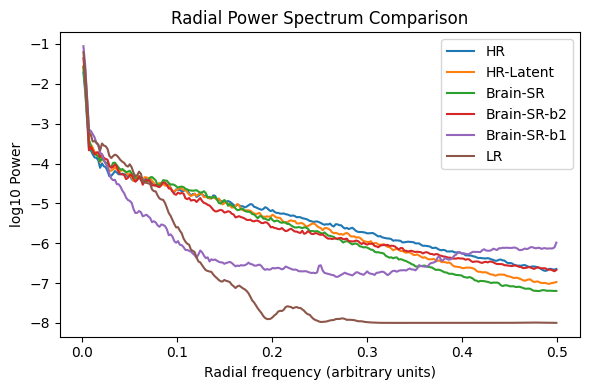

In [8]:
# SINGLE IMAGE ANALYISIS

img_to_analyze = "2560_4245.png"

img_dict = {k:osp.join(v, img_to_analyze) 
            for k,v in folders.items()}


r_centers_list = []
rps_list = []
labels = []
for k, v in img_dict.items():
    r_cent, rps = compute_rps_img(v)
    r_centers_list.append(r_cent)
    rps_list.append(rps)
    labels.append(k)

plt.figure(figsize=(6, 4))
for r_centers, rps, label in zip(r_centers_list, rps_list, labels):
    plt.plot(
        r_centers,
        np.log10(rps + 1e-8),
        label=label
    )

plt.xlabel('Radial frequency (arbitrary units)')
plt.ylabel('log10 Power')
plt.title('Radial Power Spectrum Comparison')
plt.legend()
plt.tight_layout()
plt.show()

### Compute per dataset

In [9]:
def mean_ci95(arr: np.ndarray, axis=0) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Mean ± 95% confidence interval."""
    m = arr.mean(axis=axis)
    s = arr.std(axis=axis, ddof=1)
    n = arr.shape[axis]
    sem = s / np.sqrt(max(n, 1))
    lo = m - 1.96 * sem
    hi = m + 1.96 * sem
    return m, lo, hi

In [11]:
out_dir = "/homes/gcasari/bigbrain/work_data/out_report/fft_analyze_nb"

# EXTRACT FILENAES
common = [i for i in os.listdir(list(folders.values())[0]) if i.endswith(".png")]
# sample common
common = common[::20]

# compute rcp
print(f"Found {len(common)} matched images.")
rps_bank = {k: [] for k in folders.keys()}
rho_ref = None

for name in tqdm(common, desc="Computing RPS"):
    for label, root in folders.items():
        
        rho, rps = compute_rps_img(osp.join(root, name))

        if rho_ref is None:
            rho_ref = rho
        rps_bank[label].append(rps)



Found 50 matched images.


Computing RPS:   0%|          | 0/50 [00:00<?, ?it/s]

Computing RPS: 100%|██████████| 50/50 [00:49<00:00,  1.01it/s]


In [12]:
# Stack and average
stats = {}
for label, arr_list in rps_bank.items():
    arr = np.stack(arr_list, axis=0)
    m, lo, hi = mean_ci95(arr, axis=0)
    stats[label] = (m, lo, hi)
    np.save(os.path.join(out_dir, f"rps_{label}.npy"), arr)

<Figure size 640x480 with 0 Axes>

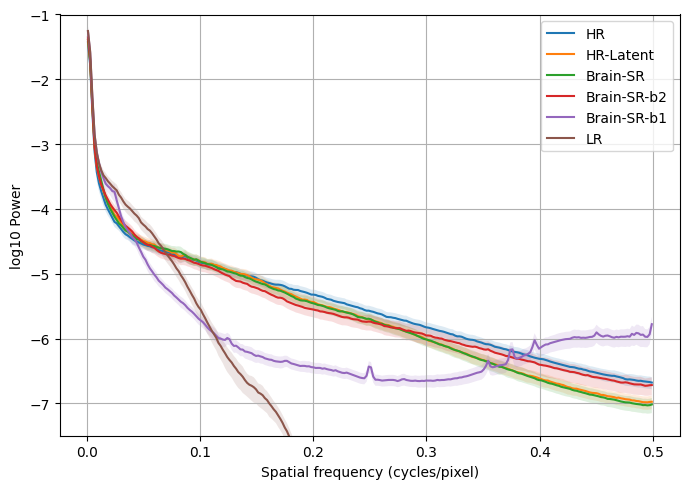

In [13]:
# Plot comparison

plt.clf()
plt.figure(figsize=(7, 5))
for label, (m, lo, hi) in stats.items():
    plt.plot(rho, np.log10(np.maximum(m, 1e-20)), label=label)
    plt.fill_between(
        rho,
        np.log10(np.maximum(lo, 1e-20)),
        np.log10(np.maximum(hi, 1e-20)),
        alpha=0.15,
    )
plt.xlabel("Spatial frequency (cycles/pixel)")
plt.ylabel("log10 Power")
plt.ylim(-7.5, -1, )
plt.legend()
plt.grid()
plt.tight_layout()


#plt.savefig(os.path.join(out_dir, "rps_comparison.png"), dpi=200)
plt.show()

# Save average curves
#np.savez(os.path.join(out_dir, "rps_averages.npz"), rho=rho_ref, **{k: v[0] for k, v in stats.items()})
#print(f"Saved results in: {out_dir}")

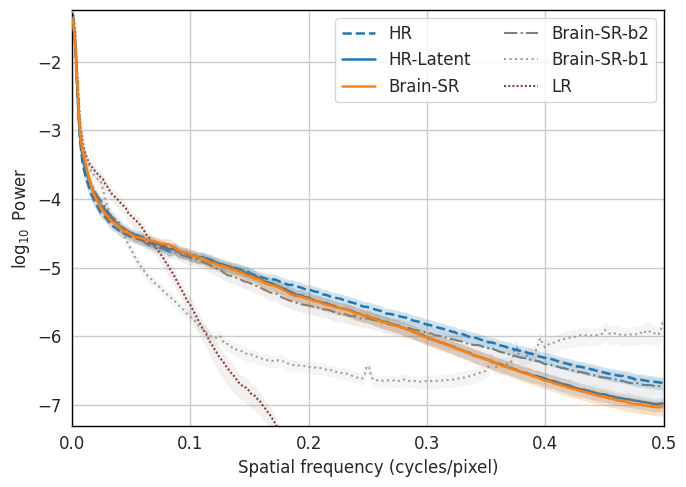

In [36]:

# --------- Publication style ---------
sns.set_style("whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2,
    "pdf.fonttype": 42,   # editable text in vector exports
    "ps.fonttype": 42,
})

# --------- Plot config ---------
order = ["HR", "HR-Latent", "Brain-SR", "Brain-SR-b2", "Brain-SR-b1", "LR"]

# Color / style map (colorblind-friendly where it matters)
C_REF = "#1f77b4"   # shared hue for HR-Latents & HR
C_MAIN = "#ff7f0e"  # highlighted Brain-SR (orange)
C_G2   = "#7f7f7f"  # mid gray
C_G3   = "#9e9e9e"  # lighter gray
C_G4   = "#894040"  # brown

style = {
    "HR-Latent": dict(color=C_REF, linestyle="-",  linewidth=1.8, zorder=6, band_alpha=0.20),
    "HR":         dict(color=C_REF, linestyle="--", linewidth=1.8, zorder=5, band_alpha=0.20),

    "Brain-SR":   dict(color=C_MAIN, linestyle="-",  linewidth=1.8, zorder=7, band_alpha=0.22),

    "Brain-SR-b2":dict(color=C_G2,  linestyle="-.", linewidth=1.5, zorder=4, band_alpha=0.12),
    "Brain-SR-b1":dict(color=C_G3,  linestyle=":",  linewidth=1.5, zorder=3, band_alpha=0.10),

    "LR":         dict(color=C_G4,  linestyle=(0,(1,1)), linewidth=1.5, zorder=2, band_alpha=0.08),
}

# Safety: ensure all requested labels exist
missing = [lbl for lbl in order if lbl not in stats]
if missing:
    raise KeyError(f"Missing series in 'stats': {missing}")

# --------- Figure ---------
fig, ax = plt.subplots(figsize=(7, 5))

rho_wavelenght = 1/rho

# Main plotting loop (use your m/lo/hi; log10 with floor)
EPS = 1e-20
for lbl in order:
    m, lo, hi = stats[lbl]
    st = style[lbl]

    y  = np.log10(np.maximum(m,  EPS))
    y0 = np.log10(np.maximum(lo, EPS))
    y1 = np.log10(np.maximum(hi, EPS))

    ax.plot(rho, y,
            label=lbl,
            color=st["color"],
            linestyle=st["linestyle"],
            linewidth=st["linewidth"],
            zorder=st["zorder"])

    ax.fill_between(rho, y0, y1,
                    color=st["color"],
                    alpha=st["band_alpha"],
                    linewidth=0,
                    zorder=st["zorder"]-0.5)

# Axes, limits, legend
ax.set_xlabel("Spatial frequency (cycles/pixel)")
ax.set_ylabel(r"$\log_{10}$ Power")
ax.set_xlim(0, 0.5)
#ax.set_xlim(rho_wavelenght.max(), rho_wavelenght.min())
#ax.set_xscale("log")
ax.set_ylim(-7.3, -1.25)
ax.grid(True, linewidth=1, alpha=1)
ax.legend(frameon=True, loc="upper right", ncol=2)
sns.despine()

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("#000000")
    spine.set_linewidth(1.0)

plt.tight_layout()

# Optional save
# out_dir = "outputs"
# os.makedirs(out_dir, exist_ok=True)
# plt.savefig(os.path.join(out_dir, "rps_comparison.pdf"), bbox_inches="tight", dpi=300)
# plt.savefig(os.path.join(out_dir, "rps_comparison.png"), bbox_inches="tight", dpi=300)

plt.show()

## TEST LOw-PASS FILTER

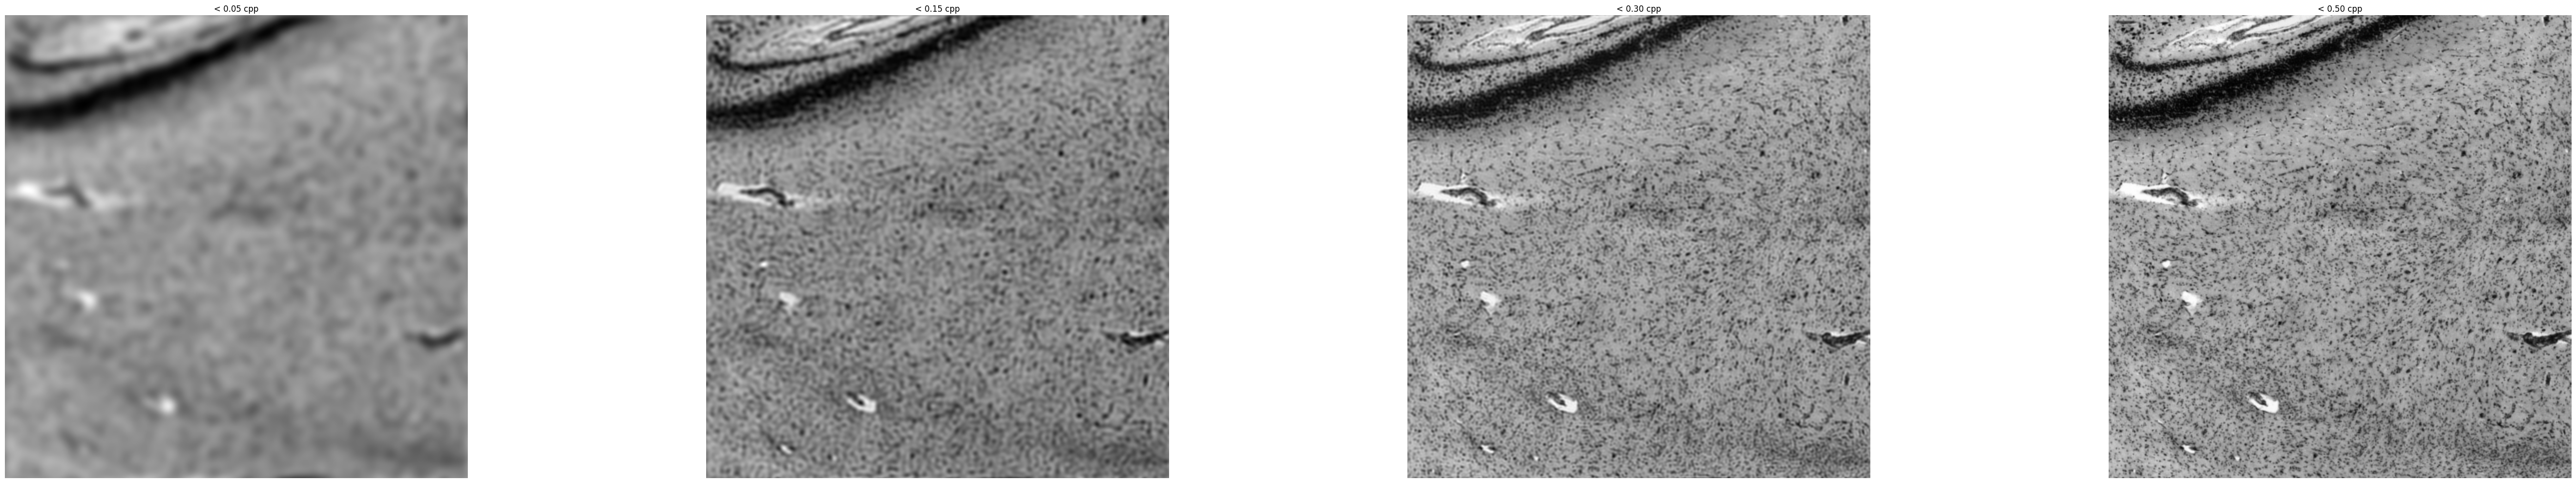

In [5]:
def lowpass_filter(img_np: np.ndarray, cutoff_cpp: float, smooth: float = 0.02):
    """
    Radial low-pass filter: keep frequencies below cutoff_cpp (cycles/pixel).
    smooth: controls the roll-off (0 = hard mask, >0 = smoother transition).
    """
    img = torch.from_numpy(img_np).float()
    H, W = img.shape

    # FFT
    F = tfft.fftshift(tfft.fft2(img, norm='ortho'))

    # Radial frequency grid (0..~0.707 for square)
    cy, cx = (H-1)/2.0, (W-1)/2.0
    y = torch.arange(H) - cy
    x = torch.arange(W) - cx
    Y, X = torch.meshgrid(y, x, indexing='ij')
    rho = torch.sqrt((Y/H)**2 + (X/W)**2)  # cycles/pixel

    # Mask: smooth logistic falloff
    if smooth > 0:
        mask = 1 / (1 + torch.exp((rho - cutoff_cpp) / smooth))
    else:
        mask = (rho <= cutoff_cpp).float()

    # Apply mask
    F_filt = F * mask

    # Inverse FFT
    img_filt = torch.real(tfft.ifft2(tfft.ifftshift(F_filt), norm='ortho'))

    return img_filt.numpy(), mask.numpy()

# ----------------------------
# Example usage
# ----------------------------
img = cv2.imread("/homes/gcasari/bigbrain/work_data/crops_datasets/test1000/high/3458_1045.png", cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0

cutoffs = [0.05, 0.15, 0.3, 0.5]  # low → high frequencies
plt.figure(figsize=(60,10))

for i, c in enumerate(cutoffs):
    img_lp, mask = lowpass_filter(img, cutoff_cpp=c, smooth=0.01)
    plt.subplot(1,len(cutoffs),i+1)
    plt.imshow(img_lp, cmap='gray')
    plt.title(f"< {c:.2f} cpp")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [24]:
def lowpass_filter(img_np: np.ndarray, cutoff_cpp: float, smooth: float = 0.02):
    """
    Radial low-pass filter: keep frequencies below cutoff_cpp (cycles/pixel).
    smooth: roll-off parameter (0 = hard mask, >0 = smooth logistic transition).
    """
    img = torch.from_numpy(img_np).float()
    H, W = img.shape

    # FFT (unitary)
    F = tfft.fftshift(tfft.fft2(img, norm='ortho'))

    # Radial frequency grid
    cy, cx = (H - 1) / 2.0, (W - 1) / 2.0
    y = torch.arange(H) - cy
    x = torch.arange(W) - cx
    Y, X = torch.meshgrid(y, x, indexing='ij')
    rho = torch.sqrt((Y / H) ** 2 + (X / W) ** 2)  # cycles/pixel

    # Mask: smooth logistic falloff
    if smooth > 0:
        mask = 1 / (1 + torch.exp((rho - cutoff_cpp) / smooth))
    else:
        mask = (rho <= cutoff_cpp).float()

    # Apply mask
    F_filt = F * mask

    # Inverse FFT
    img_filt = torch.real(tfft.ifft2(tfft.ifftshift(F_filt), norm='ortho'))

    # Normalize result to [0,1] for visualization
    out = img_filt.numpy()
    out = (out - out.min()) / (out.max() - out.min() + 1e-8)
    return out

def bandpass_filter(img_np, fmin=0.05, fmax=0.3, smooth=0.02):
    img = torch.from_numpy(img_np).float()
    H, W = img.shape
    F = tfft.fftshift(tfft.fft2(img, norm='ortho'))
    cy, cx = (H-1)/2.0, (W-1)/2.0
    y = torch.arange(H) - cy
    x = torch.arange(W) - cx
    Y, X = torch.meshgrid(y, x, indexing='ij')
    rho = torch.sqrt((Y/H)**2 + (X/W)**2)
    mask = 1 / (1 + torch.exp((rho - fmax)/smooth)) * (1 - 1 / (1 + torch.exp((rho - fmin)/smooth)))
    F_filt = F * mask
    img_bp = torch.real(tfft.ifft2(tfft.ifftshift(F_filt), norm='ortho'))
    return img_bp.numpy()


def show_filter_grid(img_dict, cutoffs, smooth=0.02):
    """
    img_dict: dict with keys -> image names, values -> numpy grayscale [0,1]
    cutoffs: list of cutoff frequencies in cycles/pixel
    """
    n_rows = len(img_dict)
    n_cols = len(cutoffs)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10*n_cols, 10*n_rows))
    if n_rows == 1:
        axes = axes[None, :]
    if n_cols == 1:
        axes = axes[:, None]

    for r, (label, img) in enumerate(img_dict.items()):
        for c, cutoff in enumerate(cutoffs):

            #img_lp = lowpass_filter(img, cutoff_cpp=cutoff, smooth=smooth)

            img_lp = bandpass_filter(img, fmin=0.3, fmax=cutoff, smooth=smooth)

            ax = axes[r, c]
            ax.imshow(img_lp, cmap='gray', vmin=0, vmax=1)
            if r == 0:
                ax.set_title(f"< {cutoff:.2f} cpp", fontsize=10)
            if c == 0:
                ax.set_ylabel(label, fontsize=10)
            ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()

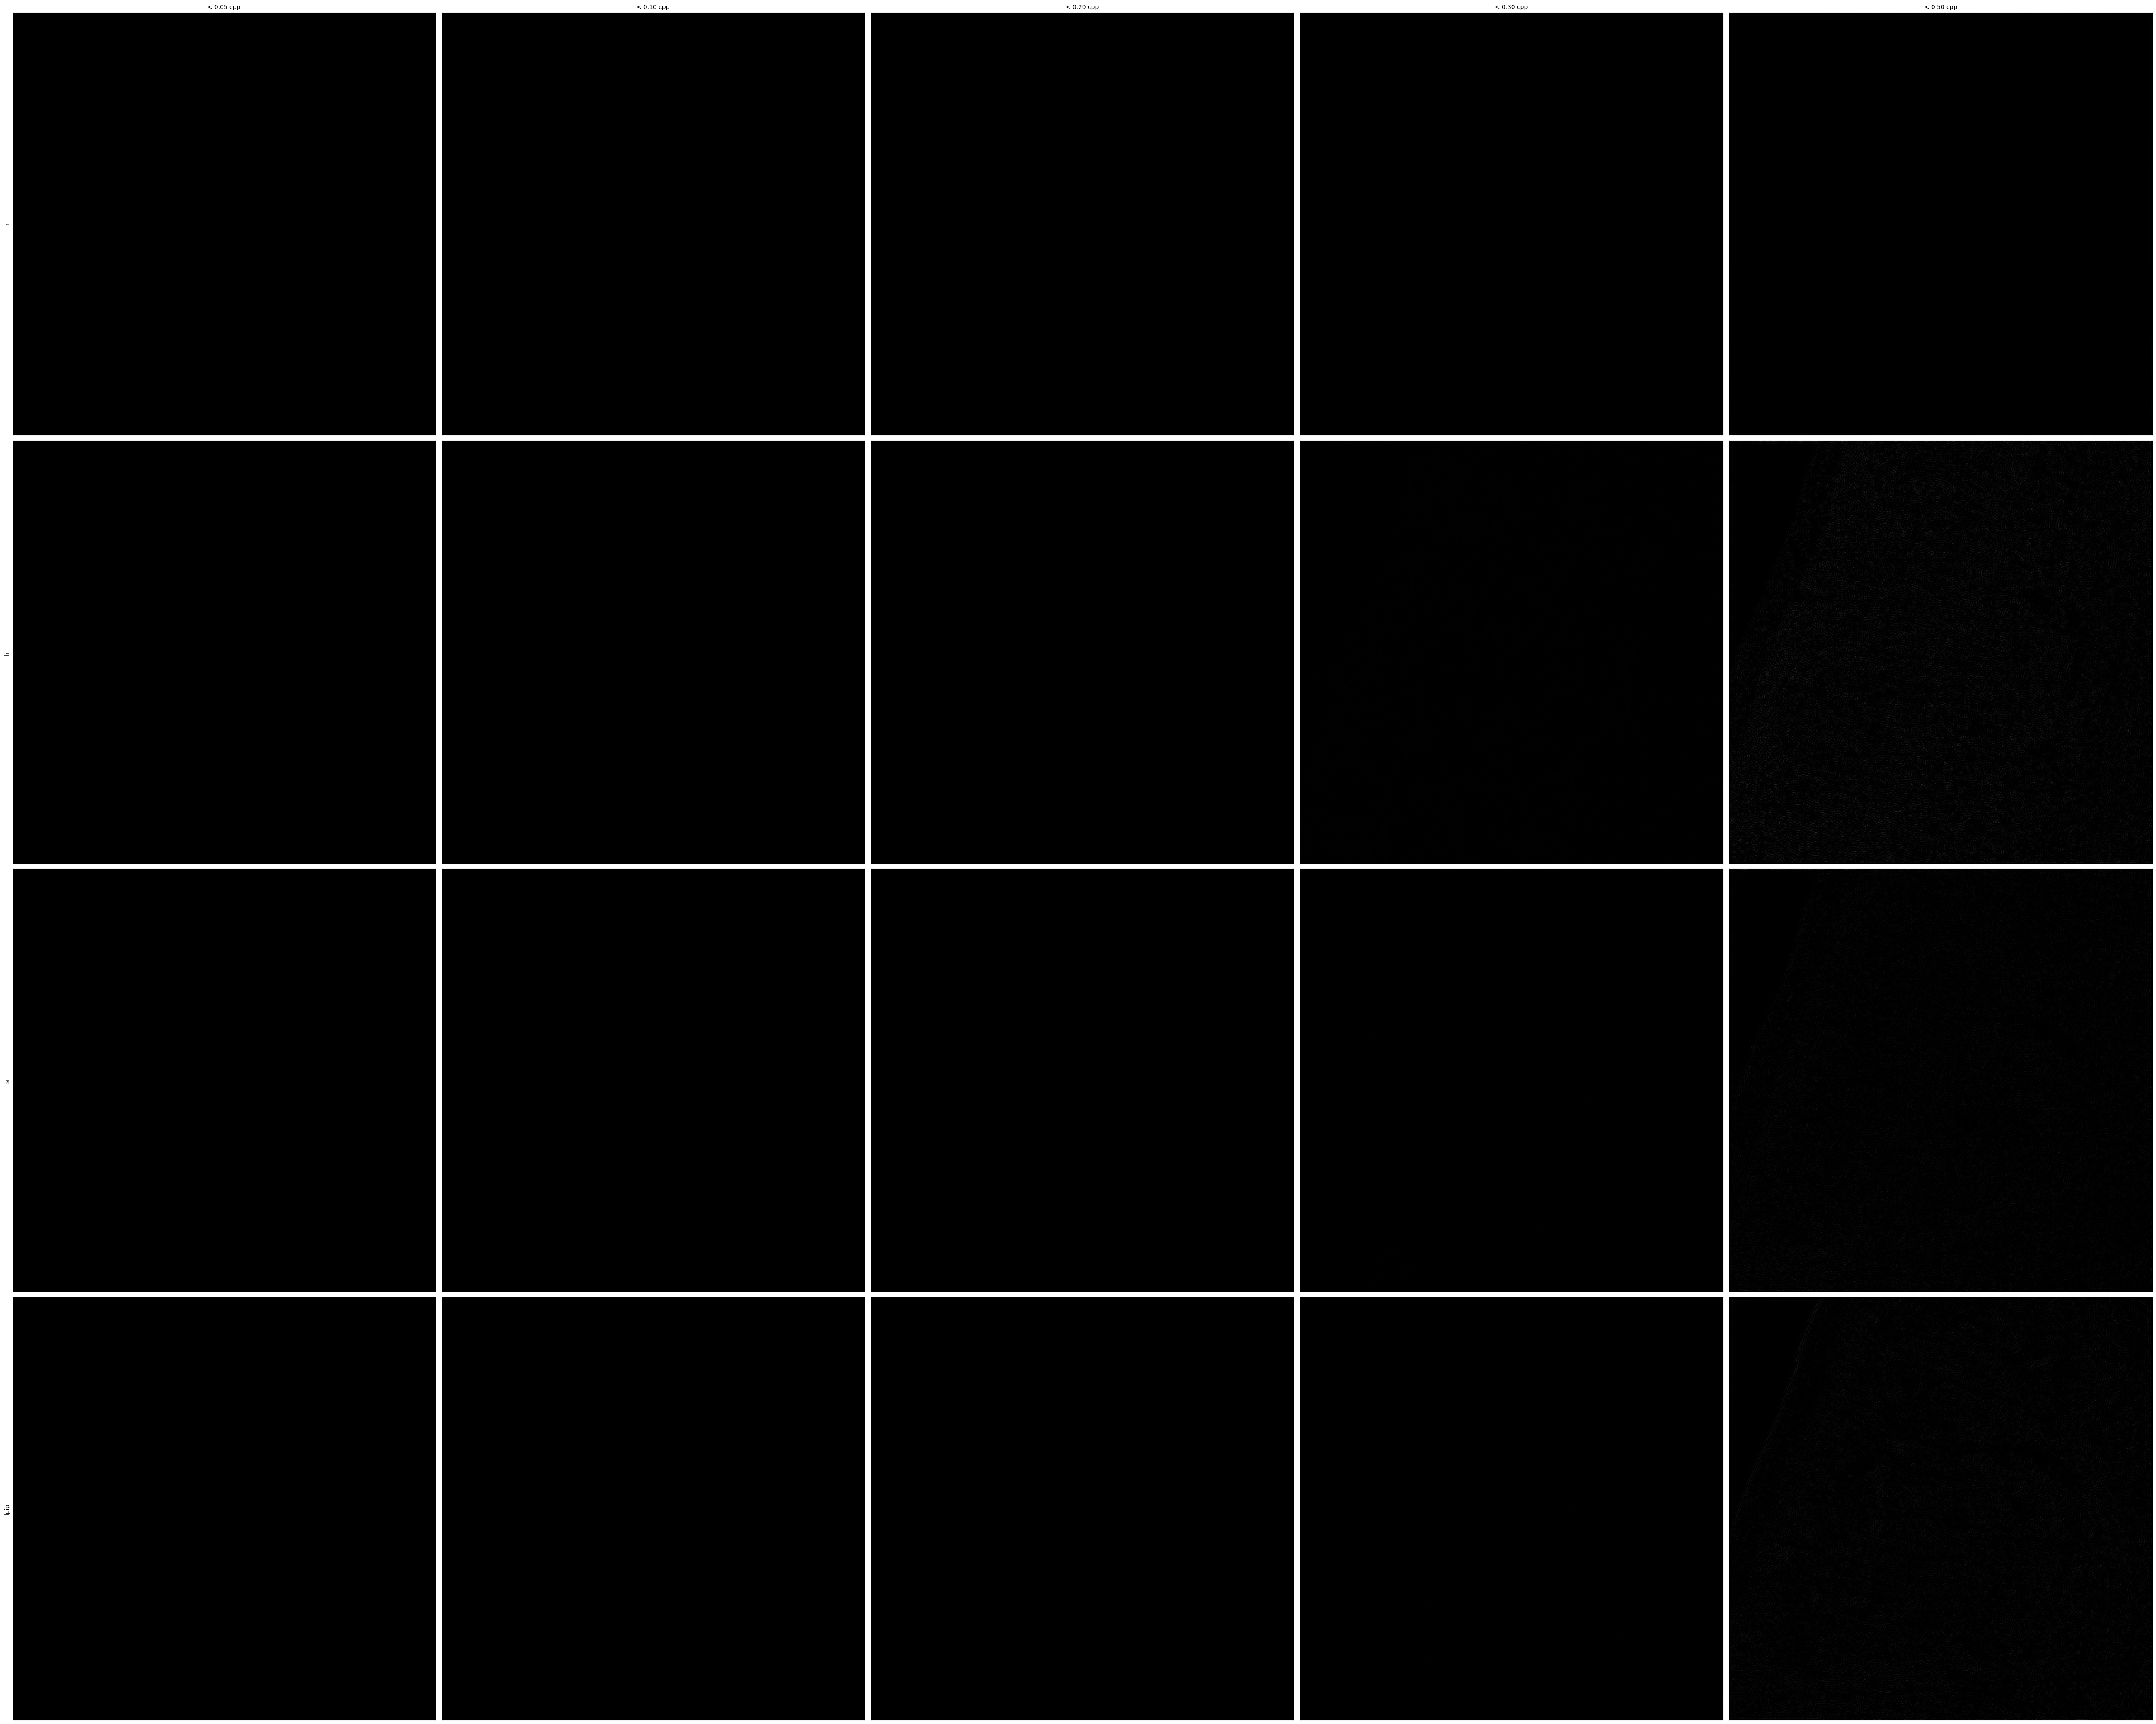

In [25]:
def load_gray(path):
    im = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    im = im.astype(np.float32) / 255.0
    if im.shape != (512, 512):
        im = cv2.resize(im, (512, 512), interpolation=cv2.INTER_CUBIC)
    return im

img_to_analyze = "2560_4245.png"

images = {
    k: load_gray(osp.join(v, img_to_analyze)) for k,v in folders.items()
}

# Cutoff frequencies (cycles/pixel)
cutoffs = [0.05, 0.10, 0.20, 0.30, 0.50]

show_filter_grid(images, cutoffs, smooth=0.01)